# ⚡ Analisi FVT + Accumulo
### Notebook interattivo per analisi produzione fotovoltaica e business plan
<div style="display:flex;align-items:center;gap:30px;margin-bottom:12px">
  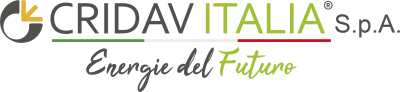
</div>


Questo notebook stima produzione FVT, autoconsumo, accumulo, prelievo da rete, immissione e ritorno economico.  
Non include consumi termici, pompa di calore, ACS o gas.

---


## 0 · Setup – Import e installazione dipendenze

In [1]:
import warnings
import re
import io
import json
from pathlib import Path
from urllib.parse import quote
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import holidays
import requests
from demandlib import bdew

warnings.simplefilter("always", UserWarning)
plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True})

# Stato globale del notebook
stato = {}

# Valori guida volutamente semplici: servono per una stima preliminare, non per sostituire una Legge 10.
# Gli ordini di grandezza sono coerenti con range pratici ricorrenti: edifici efficienti ~50 W/m² o meno,
# edifici medi/scarsi ~80–100 W/m², con correzione cautelativa per zona climatica.
W_M2_PROGETTO = {
    "nuova":   {"A/B": 25, "C": 30, "D": 35, "E": 40, "F": 45},
    "vecchia": {"A/B": 50, "C": 65, "D": 80, "E": 95, "F": 110},
}
T_MANDATA_TERMINALI = {
    "radiatori": 65.0,
    "fancoil": 45.0,
    "pavimento_radiante": 35.0,
}


def intestazione(testo, colore="#1a5276"):
    display(HTML(f'<div style="background:{colore};color:white;padding:10px 16px;border-radius:6px;font-size:15px;font-weight:bold;margin:10px 0">{testo}</div>'))

def ok(testo):
    display(HTML(f'<div style="background:#d5f5e3;color:#1e8449;padding:8px 14px;border-radius:5px;margin:4px 0">✅ {testo}</div>'))

def warn(testo):
    display(HTML(f'<div style="background:#fef9e7;color:#b7770d;padding:8px 14px;border-radius:5px;margin:4px 0">⚠️ {testo}</div>'))

def errore(testo):
    display(HTML(f'<div style="background:#fadbd8;color:#922b21;padding:8px 14px;border-radius:5px;margin:4px 0">⛔ {testo}</div>'))

def stima_potenza_progetto_kw(area_m2, zona_climatica, tipo_edificio):
    w_m2 = W_M2_PROGETTO[tipo_edificio][zona_climatica]
    return area_m2 * w_m2 / 1000.0, w_m2

def geocodifica_comune(comune, provincia=None):
    """Restituisce lat/lon da Nominatim, provando Comune+Provincia e poi Comune."""
    comune = str(comune).strip()
    provincia = str(provincia).strip() if provincia else ""
    if not comune:
        raise ValueError("Inserisci il nome del comune.")

    tentativi = []
    if provincia:
        tentativi.append(f"{comune}, {provincia}, Italia")
    tentativi.append(f"{comune}, Italia")
    tentativi.append(comune)

    headers = {"User-Agent": "stima-performance-fvt-notebook/1.0"}
    for query in tentativi:
        url = "https://nominatim.openstreetmap.org/search"
        params = {"q": query, "format": "json", "limit": 1, "countrycodes": "it"}
        r = requests.get(url, params=params, headers=headers, timeout=20)
        r.raise_for_status()
        data = r.json()
        if data:
            return float(data[0]["lat"]), float(data[0]["lon"]), data[0].get("display_name", query)

    raise ValueError(f"Comune non trovato: {comune}, {provincia}, Italia")

def scarica_tmy_pvgis(lat, lon):
    """Scarica il TMY PVGIS 5.3 in JSON e restituisce un DataFrame normalizzato."""
    url = "https://re.jrc.ec.europa.eu/api/v5_3/tmy"
    params = {"lat": lat, "lon": lon, "outputformat": "json"}
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    js = r.json()
    rows = js.get("outputs", {}).get("tmy_hourly")
    if rows is None:
        raise ValueError("Risposta PVGIS inattesa: campo outputs.tmy_hourly assente.")
    return pd.DataFrame(rows)

def normalizza_tmy(df_raw):
    """Uniforma i nomi colonna PVGIS e crea timestamp, mese, day-of-year e ora."""
    df = df_raw.copy()
    if "time(UTC)" not in df.columns:
        # PVGIS JSON usa spesso 'time(UTC)'; alcuni export possono avere 'time'.
        possibili = [c for c in df.columns if c.lower().startswith("time")]
        if possibili:
            df = df.rename(columns={possibili[0]: "time(UTC)"})
    rename = {"T2m": "T_ext_C", "G(h)": "GHI", "Gd(h)": "DHI"}
    df = df.rename(columns=rename)
    colonne = ["time(UTC)", "T_ext_C", "GHI", "DHI"]
    manc = [c for c in colonne if c not in df.columns]
    if manc:
        raise ValueError(f"Colonne TMY mancanti: {manc}")
    df = df[colonne].copy()
    df["timestamp_old"] = pd.to_datetime(df["time(UTC)"], format="%Y%m%d:%H%M", errors="coerce")
    if df["timestamp_old"].isna().all():
        df["timestamp_old"] = pd.to_datetime(df["time(UTC)"], errors="coerce")
    df = df.dropna(subset=["timestamp_old"])
    for c in ["T_ext_C", "GHI", "DHI"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["T_ext_C"])
    df["GHI"] = df["GHI"].fillna(0)
    df["DHI"] = df["DHI"].fillna(0)
    df["doy"] = df["timestamp_old"].dt.dayofyear
    df["hour"] = df["timestamp_old"].dt.hour
    df["timestamp"] = (pd.to_datetime("2025-01-01")
                       + pd.to_timedelta(df["doy"] - 1, unit="D")
                       + pd.to_timedelta(df["hour"], unit="h"))
    df["mese"] = df["timestamp"].dt.month
    return df.reset_index(drop=True)


def leggi_tmy_csv_pvgis_locale(path_tmy):
    """
    Legge un file CSV TMY PVGIS locale anche se contiene righe iniziali di metadati.
    Cerca automaticamente la riga di intestazione dei dati orari.
    """
    with open(path_tmy, "r", encoding="utf-8", errors="ignore") as f:
        righe = f.readlines()

    idx_header = None
    sep = ","

    for i, riga in enumerate(righe):
        r = riga.strip()
        if not r:
            continue

        sep_test = ";" if ";" in r and r.count(";") > r.count(",") else ","
        campi = [c.strip().replace('"', "") for c in r.split(sep_test)]

        cond_time = len(campi) > 1 and campi[0].lower().startswith("time")
        cond_pvgis = "T2m" in campi and any(c in campi for c in ["G(h)", "Gb(n)", "Gd(h)", "RH"])

        if cond_time or cond_pvgis:
            idx_header = i
            sep = sep_test
            break

    if idx_header is None:
        # Fallback: utile se il CSV è già pulito.
        return pd.read_csv(path_tmy)

    df = pd.read_csv(
        path_tmy,
        skiprows=idx_header,
        sep=sep,
        engine="python"
    )

    df.columns = [str(c).strip().replace('"', "") for c in df.columns]

    # Rimuove eventuali righe finali non orarie/metadati.
    if "T2m" in df.columns:
        df = df[pd.to_numeric(df["T2m"], errors="coerce").notna()].copy()

    return df

print("✅ Setup completato.")


✅ Setup completato.


---
## 1 · Taglie impianto FVT e accumulo


In [2]:
intestazione("🔧 STEP 1 – Taglie impianto FVT")

w_fvt  = widgets.FloatText(value=6.0,  description="FVT [kWp]:", style={"description_width":"150px"}, layout=widgets.Layout(width="320px"))
w_bess = widgets.FloatText(value=10.2, description="Batterie [kWh]:", style={"description_width":"150px"}, layout=widgets.Layout(width="320px"))

display(widgets.VBox([
    widgets.HTML("<b>Inserisci le taglie dei componenti:</b>"),
    w_fvt, w_bess,
    widgets.HTML("<i>Analisi solo elettrica: non vengono considerati pompa di calore, ACS o consumi gas.</i>")
]))

btn1 = widgets.Button(description="✔ Conferma taglie", button_style="success", layout=widgets.Layout(width="220px", margin="10px 0"))
out1 = widgets.Output()

def salva_taglie(_):
    with out1:
        clear_output()
        stato["taglia_PV"]   = float(w_fvt.value)
        stato["taglia_BESS"] = float(w_bess.value)
        ok(f"FVT={stato['taglia_PV']} kWp | Batterie={stato['taglia_BESS']} kWh")

btn1.on_click(salva_taglie)
display(btn1, out1)


Button(button_style='success', description='✔ Conferma taglie', layout=Layout(margin='10px 0', width='220px'),…

Output()

---
## 2 · Località, clima, FVT e tariffe


In [3]:
intestazione("🏠 STEP 2 – Località, clima e tariffe")

import os
import unicodedata


def nome_file_tmy_provincia(provincia):
    """
    Trasforma il nome provincia nel formato usato per i file TMY.
    Es. Pisa -> PisaTMY.csv
        La Spezia -> LaSpeziaTMY.csv
        Reggio Emilia -> ReggioEmiliaTMY.csv
        Valle d'Aosta -> ValledAostaTMY.csv
    """
    p = str(provincia).strip()
    p = unicodedata.normalize("NFKD", p).encode("ascii", "ignore").decode("ascii")
    p = p.replace("'", "").replace("’", "")
    p = "".join(ch for ch in p.title() if ch.isalnum())
    return f"{p}TMY.csv"


w_comune = widgets.Text(value="Larciano", description="Comune:", style={"description_width":"220px"}, layout=widgets.Layout(width="460px"))
w_provincia = widgets.Text(value="Pistoia", description="Provincia:", style={"description_width":"220px"}, layout=widgets.Layout(width="460px"))
w_tilt_fv = widgets.FloatText(
    value=30.0,
    description="Inclinazione FVT [°] (Default 30):",
    style={"description_width":"280px"},
    layout=widgets.Layout(width="470px")
)

w_cel = widgets.FloatText(value=0.30, description="Costo elettricità [€/kWh] (Default 0.30):", style={"description_width":"310px"}, layout=widgets.Layout(width="540px"))
w_pmg = widgets.FloatText(value=0.045, description="Prezzo vendita in rete energia FVT [€/kWh] (Default 0.045):", style={"description_width":"400px"}, layout=widgets.Layout(width="650px"))

display(widgets.VBox([
    widgets.HTML("<b>Clima e TMY:</b>"),
    widgets.HTML("<i>Il TMY viene letto automaticamente dalla cartella <code>TMY_PVGIS</code> in base alla provincia. Il comune serve per ricavare le coordinate.</i>"),
    w_comune, w_provincia,
    widgets.HTML("<b>Parametri FVT:</b>"),
    w_tilt_fv,
    widgets.HTML("<b>Tariffe energetiche:</b>"),
    w_cel, w_pmg,
]))

btn2 = widgets.Button(description="✔ Conferma", button_style="success", layout=widgets.Layout(width="220px", margin="10px 0"))
out2 = widgets.Output()

def salva_localita_tariffe(_):
    with out2:
        clear_output()
        stato["comune"] = w_comune.value.strip()
        stato["provincia"] = w_provincia.value.strip()
        stato["tilt_deg"] = float(w_tilt_fv.value)
        stato["tmy_mode"] = "locale"
        stato["tmy_df"] = None

        cartella_tmy = "TMY_PVGIS"

        try:
            lat, lon, nome = geocodifica_comune(stato["comune"], stato["provincia"])
            stato["lat"] = lat
            stato["lon"] = lon
            ok(f"Comune riconosciuto: {nome}")
        except Exception:
            stato["lat"] = 43.71667
            stato["lon"] = 10.40000
            warn("Coordinate non recuperate automaticamente. Verrà usata una localizzazione climatica di riferimento.")

        try:
            file_tmy = nome_file_tmy_provincia(stato["provincia"])
            percorso_tmy = os.path.join(cartella_tmy, file_tmy)
            if not os.path.exists(percorso_tmy):
                raise FileNotFoundError
            stato["tmy_file"] = percorso_tmy
            ok(f"File TMY provinciale trovato: {file_tmy}")
        except Exception:
            file_tmy = "PisaTMY.csv"
            percorso_tmy = os.path.join(cartella_tmy, file_tmy)
            stato["tmy_file"] = percorso_tmy
            if os.path.exists(percorso_tmy):
                warn("File TMY provinciale non trovato. Verrà usato PisaTMY.csv come profilo climatico di riferimento.")
            else:
                warn("File TMY provinciale non trovato. Anche PisaTMY.csv non è disponibile nella cartella prevista.")

        stato["c_el"] = float(w_cel.value)
        stato["PMG_el"] = float(w_pmg.value)
        ok(f"Inclinazione FVT: {stato['tilt_deg']:.0f}°")
        ok(f"c_el={stato['c_el']} €/kWh | vendita rete FVT={stato['PMG_el']} €/kWh")

btn2.on_click(salva_localita_tariffe)
display(btn2, out2)


Button(button_style='success', description='✔ Conferma', layout=Layout(margin='10px 0', width='220px'), style=…

Output()

---
## 3 · Consumi elettrici da bolletta


In [4]:
intestazione("⚡ STEP 3 – Consumi elettrici da bolletta")

w_tipo_bolletta = widgets.RadioButtons(
    options=[("Totale annuo (kWh totali, no fasce)", "totale"),
             ("Bioraria (F1 + F23)", "bioraria"),
             ("Trioraria (F1 + F2 + F3)", "trioraria"),
             ("Mensile per fascia (12 mesi × 3 fasce)", "mensile")],
    description="Tipo dati:", style={"description_width": "120px"}
)
w_profilo = widgets.RadioButtons(
    options=[("Residenziale", "residenziale"),
             ("Non residenziale / ufficio", "non_residenziale")],
    description="Profilo:", style={"description_width": "120px"}
)

# Container dinamico per i campi di input
area_input = widgets.Output()

# Widget per i vari casi
w_tot = widgets.FloatText(value=3240, description="kWh totali annui:", style={"description_width": "180px"}, layout=widgets.Layout(width="340px"))

w_F1_bio  = widgets.FloatText(value=1440, description="F1 [kWh]:",  style={"description_width":"120px"}, layout=widgets.Layout(width="280px"))
w_F23_bio = widgets.FloatText(value=1800, description="F23 [kWh]:", style={"description_width":"120px"}, layout=widgets.Layout(width="280px"))
w_F23_split = widgets.FloatSlider(value=0.30, min=0, max=1, step=0.05, description="Quota F23→F2:",
                                   style={"description_width":"160px"}, layout=widgets.Layout(width="400px"),
                                   readout_format=".0%")

w_F1_trio = widgets.FloatText(value=1440, description="F1 [kWh]:", style={"description_width":"120px"}, layout=widgets.Layout(width="280px"))
w_F2_trio = widgets.FloatText(value=960,  description="F2 [kWh]:", style={"description_width":"120px"}, layout=widgets.Layout(width="280px"))
w_F3_trio = widgets.FloatText(value=840,  description="F3 [kWh]:", style={"description_width":"120px"}, layout=widgets.Layout(width="280px"))

# Tabella mensile 12 mesi × F1/F2/F3
mesi_nomi = ["Gen","Feb","Mar","Apr","Mag","Giu","Lug","Ago","Set","Ott","Nov","Dic"]
valori_default_mensile = [
    (130, 85, 75), (115, 75, 65), (120, 80, 70), (110, 75, 65),
    (115, 77, 67), (118, 80, 70), (125, 84, 73), (128, 86, 75),
    (112, 75, 65), (118, 79, 69), (122, 81, 71), (127, 85, 74)
]
w_mese_F1 = [widgets.FloatText(value=v[0], description=f"{mesi_nomi[i]} F1:", style={"description_width":"80px"}, layout=widgets.Layout(width="200px")) for i,v in enumerate(valori_default_mensile)]
w_mese_F2 = [widgets.FloatText(value=v[1], description=f"{mesi_nomi[i]} F2:", style={"description_width":"80px"}, layout=widgets.Layout(width="200px")) for i,v in enumerate(valori_default_mensile)]
w_mese_F3 = [widgets.FloatText(value=v[2], description=f"{mesi_nomi[i]} F3:", style={"description_width":"80px"}, layout=widgets.Layout(width="200px")) for i,v in enumerate(valori_default_mensile)]

def aggiorna_input(change=None):
    with area_input:
        clear_output()
        t = w_tipo_bolletta.value
        if t == "totale":
            display(widgets.HTML("<b>Consumo totale annuo:</b>"))
            display(w_tot)
            display(widgets.HTML("<i>Il profilo orario sarà generato automaticamente dalla forma BDEW.</i>"))
        elif t == "bioraria":
            display(widgets.HTML("<b>Consumi bioraria (periodo annuo):</b>"))
            display(w_F1_bio, w_F23_bio)
        elif t == "trioraria":
            display(widgets.HTML("<b>Consumi trioraria (periodo annuo):</b>"))
            display(w_F1_trio, w_F2_trio, w_F3_trio)
        elif t == "mensile":
            display(widgets.HTML("<b>Consumi mensili per fascia (kWh):</b>"))
            righe = []
            for i in range(12):
                righe.append(widgets.HBox([w_mese_F1[i], w_mese_F2[i], w_mese_F3[i]]))
            display(widgets.VBox(righe))

w_tipo_bolletta.observe(aggiorna_input, names="value")
display(widgets.VBox([w_tipo_bolletta, w_profilo, area_input]))
aggiorna_input()

btn3 = widgets.Button(description="✔ Conferma consumi", button_style="success", layout=widgets.Layout(width="220px", margin="10px 0"))
out3 = widgets.Output()

def salva_consumi(_):
    with out3:
        clear_output()
        stato["tipo_bolletta"] = w_tipo_bolletta.value
        stato["profilo"]       = w_profilo.value
        t = w_tipo_bolletta.value
        if t == "totale":
            W = w_tot.value
            stato["bollette"] = pd.DataFrame([(1, 12, W/3, W/3, W/3)],
                                              columns=["m_start","m_end","F1_kWh","F2_kWh","F3_kWh"])
            ok(f"Consumo totale annuo: {W:,.0f} kWh (profilo BDEW auto)")
        elif t == "bioraria":
            f1 = w_F1_bio.value
            f23 = w_F23_bio.value
            q = w_F23_split.value
            f2, f3 = f23*q, f23*(1-q)
            stato["bollette"] = pd.DataFrame([(1, 12, f1, f2, f3)],
                                              columns=["m_start","m_end","F1_kWh","F2_kWh","F3_kWh"])
            ok(f"F1={f1:.0f} kWh | F2={f2:.0f} kWh | F3={f3:.0f} kWh (totale {f1+f2+f3:.0f} kWh)")
        elif t == "trioraria":
            f1,f2,f3 = w_F1_trio.value, w_F2_trio.value, w_F3_trio.value
            stato["bollette"] = pd.DataFrame([(1, 12, f1, f2, f3)],
                                              columns=["m_start","m_end","F1_kWh","F2_kWh","F3_kWh"])
            ok(f"F1={f1:.0f} kWh | F2={f2:.0f} kWh | F3={f3:.0f} kWh (totale {f1+f2+f3:.0f} kWh)")
        elif t == "mensile":
            righe = []
            for i in range(12):
                righe.append((i+1, i+1, w_mese_F1[i].value, w_mese_F2[i].value, w_mese_F3[i].value))
            stato["bollette"] = pd.DataFrame(righe, columns=["m_start","m_end","F1_kWh","F2_kWh","F3_kWh"])
            tot = sum(w_mese_F1[i].value + w_mese_F2[i].value + w_mese_F3[i].value for i in range(12))
            ok(f"Dati mensili inseriti – totale annuo: {tot:,.0f} kWh")

btn3.on_click(salva_consumi)
display(btn3, out3)

Button(button_style='success', description='✔ Conferma consumi', layout=Layout(margin='10px 0', width='220px')…

Output()

---
## 4 · Costi FVT, accumulo e incentivi


In [5]:
intestazione("💶 STEP 4 – Costi FVT, accumulo e incentivi")

display(widgets.HTML("<b>Costi di investimento (IVA inclusa):</b>"))
w_c_fvt  = widgets.FloatText(value=10935, description="Costo FVT [€]:", style={"description_width":"250px"}, layout=widgets.Layout(width="430px"))
w_c_bess = widgets.FloatText(value=5760,  description="Costo Batterie [€]:", style={"description_width":"250px"}, layout=widgets.Layout(width="430px"))
display(w_c_fvt, w_c_bess)

display(widgets.HTML("<br><b>Incentivi e detrazioni:</b>"))
w_incentivo = widgets.FloatText(value=0, description="Contributo/incentivo una tantum [€]:", style={"description_width":"300px"}, layout=widgets.Layout(width="520px"))
w_aliq  = widgets.RadioButtons(
    options=[("50%", 0.50), ("36%", 0.36), ("Nessuna detrazione", 0.0)],
    description="Detrazione IRPEF:", style={"description_width":"160px"}
)
w_anni_det = widgets.IntSlider(value=10, min=5, max=10, step=5, description="Anni detrazione (Default 10):",
                                style={"description_width":"230px"}, layout=widgets.Layout(width="500px"))
display(w_incentivo, w_aliq, w_anni_det)

display(widgets.HTML("<br><b>Parametri analisi economica:</b>"))
w_anni_analisi = widgets.IntSlider(value=20, min=10, max=30, step=5, description="Orizzonte analisi [anni] (Default 20):",
                                    style={"description_width":"280px"}, layout=widgets.Layout(width="560px"))
w_cresc_el  = widgets.FloatSlider(value=0.02, min=0, max=0.10, step=0.005,
                                   description="Cresc. costo el. [%/a] (Default 2%):", style={"description_width":"280px"},
                                   layout=widgets.Layout(width="560px"), readout_format=".1%")
w_tasso_sc  = widgets.FloatSlider(value=0.03, min=0, max=0.10, step=0.005,
                                   description="Tasso sconto [%/a] (Default 3%):", style={"description_width":"280px"},
                                   layout=widgets.Layout(width="560px"), readout_format=".1%")
display(w_anni_analisi, w_cresc_el, w_tasso_sc)

btn5 = widgets.Button(description="✔ Conferma investimento", button_style="success", layout=widgets.Layout(width="260px", margin="10px 0"))
out5 = widgets.Output()

def salva_costi(_):
    with out5:
        clear_output()
        stato["costo_FVT"] = float(w_c_fvt.value)
        stato["costo_BESS"] = float(w_c_bess.value)
        stato["incentivo"] = float(w_incentivo.value)
        stato["aliquota_det"] = float(w_aliq.value)
        stato["anni_det"] = int(w_anni_det.value)
        stato["orizzonte"] = int(w_anni_analisi.value)
        stato["cresc_el"] = float(w_cresc_el.value)
        stato["tasso_sconto"] = float(w_tasso_sc.value)
        inv_tot = stato["costo_FVT"] + stato["costo_BESS"] - stato["incentivo"]
        ok(f"Investimento totale netto: {inv_tot:,.0f} €")
        ok(f"Detrazione {stato['aliquota_det']*100:.0f}% in {stato['anni_det']} anni | Orizzonte {stato['orizzonte']} anni")

btn5.on_click(salva_costi)
display(btn5, out5)


HTML(value='<b>Costi di investimento (IVA inclusa):</b>')

FloatText(value=10935.0, description='Costo FVT [€]:', layout=Layout(width='430px'), style=DescriptionStyle(de…

FloatText(value=5760.0, description='Costo Batterie [€]:', layout=Layout(width='430px'), style=DescriptionStyl…

HTML(value='<br><b>Incentivi e detrazioni:</b>')

FloatText(value=0.0, description='Contributo/incentivo una tantum [€]:', layout=Layout(width='520px'), style=D…

...

IntSlider(value=20, description='Orizzonte analisi [anni] (Default 20):', layout=Layout(width='560px'), max=30…

FloatSlider(value=0.02, description='Cresc. costo el. [%/a] (Default 2%):', layout=Layout(width='560px'), max=…

FloatSlider(value=0.03, description='Tasso sconto [%/a] (Default 3%):', layout=Layout(width='560px'), max=0.1,…

Button(button_style='success', description='✔ Conferma investimento', layout=Layout(margin='10px 0', width='26…

Output()

---
## 5 · 🚀 Esegui il calcolo FVT


In [7]:
intestazione("🚀 STEP 5 – Calcolo FVT + accumulo", colore="#1a5276")

campi_obbligatori = ["taglia_PV", "taglia_BESS", "c_el", "bollette", "costo_FVT"]
nomi_campi = {
    "taglia_PV": "taglia FVT",
    "taglia_BESS": "taglia batterie",
    "c_el": "tariffe energetiche",
    "bollette": "consumi da bolletta",
    "costo_FVT": "costi investimento",
}

btn_run = widgets.Button(description="▶ CALCOLA ORA", button_style="danger",
                         layout=widgets.Layout(width="260px", height="45px", margin="10px 0"))
out_run = widgets.Output()
display(btn_run, out_run)

def esegui_calcolo(_):
    with out_run:
        clear_output()

        mancanti = [c for c in campi_obbligatori if c not in stato]
        if mancanti:
            mancanti_label = [nomi_campi.get(c, c) for c in mancanti]
            display(HTML(f'<div style="background:#fadbd8;color:#922b21;padding:10px;border-radius:5px">'
                         f'⛔ Completa prima questi passaggi: {mancanti_label}</div>'))
            return

        # ── Costanti fisse ───────────────────────────────────────────────────
        AZ_DEG = 0.0
        ALBEDO = 0.20
        eta_sis = 0.90
        SOC_min_frac = 0.10
        SOC_max_frac = 0.95
        eta_ch = 0.95
        eta_dis = 0.95
        P_ch_max_kW = 2.5
        P_dis_max_kW = 2.5

        # ── Estrai dallo stato ───────────────────────────────────────────────
        taglia_PV = stato["taglia_PV"]
        taglia_BESS = stato["taglia_BESS"]
        LAT_DEG = stato.get("lat", 43.80)
        TILT_DEG = stato.get("tilt_deg", 30.0)
        c_el = stato["c_el"]
        PMG_el = stato.get("PMG_el", 0.045)
        bollette = stato["bollette"]

        # ── STEP A: carica TMY ───────────────────────────────────────────────
        print("📂 Caricamento TMY...")
        try:
            if stato.get("tmy_df") is not None:
                df = normalizza_tmy(stato["tmy_df"])
                fonte_tmy = "TMY caricato automaticamente"
            else:
                path_tmy = stato.get("tmy_file", "")
                if not path_tmy:
                    raise FileNotFoundError("Percorso file TMY non impostato nello STEP 2.")
                if not os.path.exists(path_tmy):
                    raise FileNotFoundError(f"File TMY non trovato: {path_tmy}")
                if str(path_tmy).lower().endswith(".json"):
                    with open(path_tmy, "r", encoding="utf-8") as f:
                        js = json.load(f)
                    rows = js.get("outputs", {}).get("tmy_hourly", js if isinstance(js, list) else None)
                    if rows is None:
                        raise ValueError("JSON TMY non riconosciuto.")
                    df_raw = pd.DataFrame(rows)
                else:
                    df_raw = leggi_tmy_csv_pvgis_locale(path_tmy)
                df = normalizza_tmy(df_raw)
                fonte_tmy = "file TMY locale"

            if len(df) == 0:
                raise ValueError("Il TMY è stato letto, ma non contiene righe orarie valide.")

            colonne_richieste = ["timestamp", "mese", "doy", "hour", "T_ext_C", "GHI", "DHI"]
            mancanti_tmy = [c for c in colonne_richieste if c not in df.columns]
            if mancanti_tmy:
                raise ValueError(f"Colonne TMY mancanti dopo normalizzazione: {mancanti_tmy}")

        except Exception as e:
            errore(f"TMY non disponibile ({e}). Verifica percorso del file locale nello STEP 2.")
            return

        ok(f"TMY caricato da {fonte_tmy}: {len(df)} righe | T_ext [{df['T_ext_C'].min():.1f}, {df['T_ext_C'].max():.1f}] °C")

        # ── STEP B: trasposizione Perez ──────────────────────────────────────
        print("☀️  Trasposizione irradianza (Perez)...")
        LAT = np.radians(LAT_DEG)
        TILT = np.radians(TILT_DEG)
        AZ = np.radians(AZ_DEG)
        df["GHI"] = pd.to_numeric(df["GHI"], errors="coerce").fillna(0).clip(lower=0)
        df["DHI"] = pd.to_numeric(df["DHI"], errors="coerce").fillna(0).clip(lower=0)
        doy_v = df["doy"].values.astype(float)
        hour_v = df["hour"].values.astype(float) + 0.5
        B_ang = 2*np.pi/365*(doy_v-1)
        decl_v = (0.006918 - 0.399912*np.cos(B_ang) + 0.070257*np.sin(B_ang)
                  - 0.006758*np.cos(2*B_ang) + 0.000907*np.sin(2*B_ang)
                  - 0.002697*np.cos(3*B_ang) + 0.00148*np.sin(3*B_ang))
        ET_v = (0.000075 + 0.001868*np.cos(B_ang) - 0.032077*np.sin(B_ang)
                - 0.014615*np.cos(2*B_ang) - 0.04089*np.sin(B_ang))*(229.18/60)
        omega_v = np.radians(15*(hour_v+ET_v-12))
        sin_alt = np.clip(np.sin(LAT)*np.sin(decl_v)+np.cos(LAT)*np.cos(decl_v)*np.cos(omega_v), -1, 1)
        zen_v = np.pi/2 - np.arcsin(sin_alt)
        cos_z = np.maximum(np.cos(zen_v), 1e-6)
        GHI_v = df["GHI"].values
        DHI_v = df["DHI"].values
        DNI_v = np.where((zen_v < np.radians(85)) & (GHI_v > DHI_v), (GHI_v-DHI_v)/cos_z, 0.0).clip(0)
        df["DNI"] = DNI_v
        cos_aoi = np.clip(
            np.sin(decl_v)*np.sin(LAT)*np.cos(TILT) - np.sin(decl_v)*np.cos(LAT)*np.sin(TILT)*np.cos(AZ)
            + np.cos(decl_v)*np.cos(LAT)*np.cos(TILT)*np.cos(omega_v)
            + np.cos(decl_v)*np.sin(LAT)*np.sin(TILT)*np.cos(AZ)*np.cos(omega_v)
            + np.cos(decl_v)*np.sin(TILT)*np.sin(AZ)*np.sin(omega_v), 0, 1)
        E0_sol = 1367.0
        E_ext = E0_sol*(1+0.033*np.cos(B_ang))
        I0h = np.maximum(E_ext*np.cos(zen_v), 0)
        with np.errstate(divide="ignore", invalid="ignore"):
            eps_v = np.where(DHI_v > 0, ((DHI_v+DNI_v)/np.maximum(DHI_v, 1e-6)+5.535e-6*zen_v**3)/(1+5.535e-6*zen_v**3), 1.0)
            delta_v = np.where(I0h > 0, DHI_v/I0h, 0.0)
        eps_bins_p = [1.000,1.065,1.230,1.500,1.950,2.800,4.500,6.200,np.inf]
        eb = (np.digitize(eps_v, eps_bins_p)-1).clip(0, 7)
        F_coeff_p = np.array([[-0.0083,0.5877,-0.0621,-0.0596,0.0721,-0.0220], [0.1299,0.6826,-0.1514,-0.0189,0.0660,-0.0289],
                              [0.3297,0.4869,-0.2211,0.0554,-0.0640,-0.0261], [0.5682,0.1875,-0.2951,0.1089,-0.1519,-0.0140],
                              [0.8730,-0.3920,-0.3616,0.2260,-0.4620,0.0012], [1.1326,-1.2367,-0.4118,0.2880,-0.8230,0.0559],
                              [1.0601,-1.5999,-0.3589,0.2640,-1.1270,0.1314], [0.6777,-0.3273,-0.2504,0.1560,-1.3770,0.2506]])
        F1 = np.maximum(0, F_coeff_p[eb,0] + F_coeff_p[eb,1]*delta_v + F_coeff_p[eb,2]*zen_v)
        F2 = F_coeff_p[eb,3] + F_coeff_p[eb,4]*delta_v + F_coeff_p[eb,5]*zen_v
        a_p = np.maximum(0, cos_aoi)
        b_p = np.maximum(np.cos(np.radians(85)), np.cos(zen_v))
        D_perez = np.maximum(0, DHI_v*((1-F1)*(1+np.cos(TILT))/2 + F1*a_p/b_p + F2*np.sin(TILT)))
        df["G_tilt_Wm2"] = np.maximum(0, DNI_v*cos_aoi + D_perez + GHI_v*ALBEDO*(1-np.cos(TILT))/2)
        df["G_tilt_Wm2"] = pd.to_numeric(df["G_tilt_Wm2"], errors="coerce").fillna(0).clip(lower=0)
        ok(f"GHI annuo: {df['GHI'].sum()/1000:.0f} kWh/m² | G_tilt: {df['G_tilt_Wm2'].sum()/1000:.0f} kWh/m² | tilt FVT: {TILT_DEG:.0f}°")

        # ── STEP C: profilo elettrico utenza ────────────────────────────────
        print("🏠 Profilo consumi elettrici...")
        W_a_tot = bollette[["F1_kWh", "F2_kWh", "F3_kWh"]].sum().sum()
        year = int(df["timestamp"].dt.year.iloc[0])
        tipo_profilo = "h0_dyn" if stato.get("profilo", "residenziale") == "residenziale" else "g0"
        try:
            e_slp = bdew.ElecSlp(year=year)
            profili_scalati = e_slp.get_scaled_profiles({tipo_profilo: W_a_tot})
            profilo_h = profili_scalati.resample("h").sum()
            df["E_base_h_kWh"] = profilo_h.values[:len(df)]
        except Exception as e:
            warn(f"Errore BDEW ({e}), uso distribuzione uniforme")
            df["E_base_h_kWh"] = W_a_tot / len(df)

        anni_ts = df["timestamp"].dt.year.unique()
        it_hol = holidays.country_holidays("IT", years=anni_ts)
        def fascia_arera(ts):
            if ts.weekday() == 6 or ts.date() in it_hol:
                return "F3"
            h = ts.hour
            if ts.weekday() == 5:
                return "F2" if 7 <= h < 23 else "F3"
            if 8 <= h < 19:
                return "F1"
            if h == 7 or 19 <= h < 23:
                return "F2"
            return "F3"

        df["fascia"] = df["timestamp"].apply(fascia_arera)
        df["E_base_raw"] = df["E_base_h_kWh"].copy()
        df["E_base_h_kWh"] = 0.0
        for _, bol in bollette.iterrows():
            mask = df["mese"].between(bol["m_start"], bol["m_end"])
            sub = df.loc[mask]
            raw_f = sub.groupby("fascia")["E_base_raw"].sum()
            k = {}
            for f in ["F1", "F2", "F3"]:
                e_bol = bol[f"{f}_kWh"]
                e_raw = raw_f.get(f, 0.0)
                k[f] = e_bol/e_raw if e_raw > 0 else 0.0
            df.loc[mask, "E_base_h_kWh"] = sub["E_base_raw"].values * sub["fascia"].map(k).values
        ok(f"Profilo elettrico calibrato: {df['E_base_h_kWh'].sum():,.0f} kWh/a")

        # ── STEP D: simulazione FVT + batteria ──────────────────────────────
        print("🔋 Simulazione FVT + accumulo...")
        df["E_PV_h_kWh"] = (taglia_PV * df["G_tilt_Wm2"] / 1000 * eta_sis).clip(lower=0)
        df["E_load_h_kWh"] = df["E_base_h_kWh"]
        df["E_surplus_h"] = np.maximum(0, df["E_PV_h_kWh"] - df["E_load_h_kWh"])
        df["E_deficit_h"] = np.maximum(0, df["E_load_h_kWh"] - df["E_PV_h_kWh"])

        C_bat = taglia_BESS
        SOC_min = C_bat * SOC_min_frac
        SOC_max = C_bat * SOC_max_frac
        n = len(df)
        SOC = np.zeros(n)
        E_ch = np.zeros(n)
        E_dis = np.zeros(n)
        E_grid = np.zeros(n)
        E_export = np.zeros(n)
        soc_now = SOC_min if C_bat > 0 else 0.0
        for i in range(n):
            surplus = df.at[i, "E_surplus_h"]
            deficit = df.at[i, "E_deficit_h"]
            SOC[i] = soc_now
            cap_res = max(0, SOC_max - soc_now)
            e_ch = min(surplus, P_ch_max_kW, cap_res/eta_ch if eta_ch > 0 else 0)
            soc_now += eta_ch * e_ch
            E_ch[i] = e_ch
            en_disp = max(0, (soc_now - SOC_min) * eta_dis)
            e_dis = min(deficit, P_dis_max_kW, en_disp)
            soc_now -= e_dis/eta_dis if eta_dis > 0 else 0
            E_dis[i] = e_dis
            E_grid[i] = deficit - e_dis
            E_export[i] = surplus - e_ch
        df["SOC_kWh"] = SOC
        df["E_ch_h"] = E_ch
        df["E_dis_h"] = E_dis
        df["E_grid_h"] = E_grid
        df["E_export_h"] = E_export

        E_load_tot = df["E_load_h_kWh"].sum()
        E_PV_tot = df["E_PV_h_kWh"].sum()
        E_grid_tot = df["E_grid_h"].sum()
        E_export_tot = df["E_export_h"].sum()
        autoconsumo = E_load_tot - E_grid_tot
        copertura_carico = autoconsumo/E_load_tot if E_load_tot > 0 else 0
        quota_ac_PV = autoconsumo/E_PV_tot if E_PV_tot > 0 else 0

        # ── STEP E: analisi economica ───────────────────────────────────────
        print("💶 Analisi economica...")
        spesa_base_el_y1 = E_load_tot * c_el
        spesa_post_el_y1 = E_grid_tot * c_el - E_export_tot * PMG_el
        risparmio_annuo = spesa_base_el_y1 - spesa_post_el_y1

        costo_FVT = stato["costo_FVT"]
        costo_BESS = stato["costo_BESS"]
        incentivo = stato.get("incentivo", 0.0)
        aliq = stato["aliquota_det"]
        anni_det = stato["anni_det"]
        orizzonte = stato["orizzonte"]
        cresc_el = stato["cresc_el"]
        tasso_sc = stato["tasso_sconto"]

        inv_tot = costo_FVT + costo_BESS - incentivo
        base_detrazione = max(0, costo_FVT + costo_BESS - incentivo)
        det_annua = aliq * base_detrazione / anni_det if aliq > 0 else 0.0

        anni_list = []
        CF_list = []
        ris_list = []
        sb_list = []
        se_list = []
        for anno in range(0, orizzonte+1):
            if anno == 0:
                CF_list.append(-inv_tot)
                ris_list.append(0)
                sb_list.append(0)
                se_list.append(0)
            else:
                k_el = (1 + cresc_el)**(anno-1)
                sb = spesa_base_el_y1 * k_el
                se = spesa_post_el_y1 * k_el
                ris = sb - se
                cf = ris + (det_annua if anno <= anni_det else 0)
                CF_list.append(cf)
                ris_list.append(ris)
                sb_list.append(sb)
                se_list.append(se)
            anni_list.append(anno)

        df_cf = pd.DataFrame({"anno": anni_list, "risparmio": ris_list, "spesa_base": sb_list, "spesa_post": se_list, "CF": CF_list})
        df_cf["fd"] = 1/(1+tasso_sc)**df_cf["anno"]
        df_cf["CF_att"] = df_cf["CF"] * df_cf["fd"]
        df_cf["CF_cum"] = df_cf["CF"].cumsum()
        df_cf["CF_att_cum"] = df_cf["CF_att"].cumsum()
        VAN = df_cf["CF_att"].sum()

        def pb_interp(anni_s, cum_s):
            aa = anni_s.values
            cc = cum_s.values
            for i in range(1, len(cc)):
                if cc[i] >= 0 and cc[i-1] < 0:
                    return aa[i-1] + (-cc[i-1])/(cc[i]-cc[i-1])*(aa[i]-aa[i-1])
            return None

        payback = pb_interp(df_cf["anno"], df_cf["CF_cum"])
        payback_att = pb_interp(df_cf["anno"], df_cf["CF_att_cum"])

        stato["risultati"] = {
            "copertura_carico": copertura_carico,
            "quota_ac_PV": quota_ac_PV,
            "risparmio_annuo": risparmio_annuo,
            "payback": payback,
            "payback_att": payback_att,
            "VAN": VAN,
            "E_PV_tot": E_PV_tot,
            "E_load_tot": E_load_tot,
            "E_grid_tot": E_grid_tot,
            "E_export_tot": E_export_tot,
            "autoconsumo": autoconsumo,
            "inv_tot": inv_tot,
            "df_cf": df_cf,
            "df": df,
        }

        display(HTML('<hr><h3 style="color:#1a5276">📊 RISULTATI FVT</h3>'))
        display(HTML(f"""
        <table style="border-collapse:collapse;width:100%;font-size:14px">
        <tr style="background:#1a5276;color:white"><th colspan=2 style="padding:8px">⚡ Energia elettrica</th></tr>
        <tr><td style="padding:6px 12px">Produzione FVT annua</td><td><b>{E_PV_tot:,.0f} kWh</b></td></tr>
        <tr style="background:#f2f3f4"><td style="padding:6px 12px">Consumo elettrico annuo</td><td><b>{E_load_tot:,.0f} kWh</b></td></tr>
        <tr><td style="padding:6px 12px">Autoconsumo annuo</td><td><b>{autoconsumo:,.0f} kWh</b></td></tr>
        <tr style="background:#f2f3f4"><td style="padding:6px 12px">Prelievo da rete</td><td><b>{E_grid_tot:,.0f} kWh</b></td></tr>
        <tr><td style="padding:6px 12px">Immissione in rete</td><td><b>{E_export_tot:,.0f} kWh</b></td></tr>
        <tr style="background:#f2f3f4"><td style="padding:6px 12px">Copertura consumi con FVT+Batterie</td><td><b style="color:#1a5276">{copertura_carico*100:.1f}%</b></td></tr>
        <tr><td style="padding:6px 12px">Quota produzione FVT autoconsumata</td><td><b>{quota_ac_PV*100:.1f}%</b></td></tr>
        <tr style="background:#1a5276;color:white"><th colspan=2 style="padding:8px">💶 Economia</th></tr>
        <tr><td style="padding:6px 12px">Spesa elettrica ante intervento</td><td><b>{spesa_base_el_y1:,.0f} €</b></td></tr>
        <tr style="background:#f2f3f4"><td style="padding:6px 12px">Spesa netta post intervento</td><td><b>{spesa_post_el_y1:,.0f} €</b></td></tr>
        <tr><td style="padding:6px 12px">Risparmio annuo (anno 1)</td><td><b style="color:#1e8449">{risparmio_annuo:,.0f} €</b></td></tr>
        <tr style="background:#f2f3f4"><td style="padding:6px 12px">Investimento netto</td><td><b>{inv_tot:,.0f} €</b></td></tr>
        <tr><td style="padding:6px 12px">Payback semplice</td><td><b>{f'{payback:.1f} anni' if payback else 'non raggiunto'}</b></td></tr>
        <tr style="background:#f2f3f4"><td style="padding:6px 12px">Payback attualizzato</td><td><b>{f'{payback_att:.1f} anni' if payback_att else 'non raggiunto'}</b></td></tr>
        <tr><td style="padding:6px 12px">VAN a {orizzonte} anni</td><td><b style="color:{'#1e8449' if VAN>=0 else '#922b21'}">{VAN:,.0f} €</b></td></tr>
        </table>
        """))

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        ax = axes[0]
        ax.bar(df_cf["anno"], df_cf["CF_att"], alpha=0.6, label="CF att. annuo")
        ax.plot(df_cf["anno"], df_cf["CF_att_cum"], "-o", lw=2, ms=4, label="VAN cumulato")
        ax.axhline(0, lw=0.8, ls="--")
        if payback_att:
            ax.axvline(payback_att, lw=1.2, ls=":", label=f"PB att = {payback_att:.1f} a")
        ax.set_xlabel("Anno")
        ax.set_ylabel("€")
        ax.set_title("Andamento VAN nel tempo")
        ax.legend(loc="lower right")

        ax2 = axes[1]
        df_m = df.groupby("mese").agg(FVT=("E_PV_h_kWh", "sum"), Carico=("E_load_h_kWh", "sum"), Rete=("E_grid_h", "sum"), Export=("E_export_h", "sum")).reset_index()
        nomi_m = ["G", "F", "M", "A", "M", "G", "L", "A", "S", "O", "N", "D"]
        x = df_m["mese"]
        ax2.bar(x-0.2, df_m["Carico"], 0.4, label="Carico")
        ax2.bar(x+0.2, df_m["FVT"], 0.4, label="Prod. FVT")
        ax2.plot(
            x,
            df_m["Rete"],
            "-o",
            lw=1.5,
            ms=4,
            label="Prelievo rete",
            color="#e74c3c"
        )
        ax2.plot(
            x,
            df_m["Export"],
            "-o",
            lw=1.5,
            ms=4,
            label="Immissione",
            color="#27ae60"
        )
        ax2.set_xticks(x)
        ax2.set_xticklabels(nomi_m)
        ax2.set_xlabel("Mese")
        ax2.set_ylabel("kWh")
        ax2.set_title("Bilancio energetico mensile")
        ax2.legend()

        plt.tight_layout()
        plt.show()
        print("\n✅ Calcolo FVT completato. Vedi la cella successiva per i grafici stagionali dettagliati.")

btn_run.on_click(esegui_calcolo)


Button(button_style='danger', description='▶ CALCOLA ORA', layout=Layout(height='45px', margin='10px 0', width…

Output()

---
## 6 · Grafici stagionali dettagliati (opzionale)


In [ ]:
intestazione("📈 STEP 6 – Grafici stagionali", colore="#2471a3")

btn7 = widgets.Button(description="📊 Mostra grafici stagionali", button_style="info", layout=widgets.Layout(width="260px", margin="10px 0"))
out7 = widgets.Output()

def mostra_grafici_stagionali(_):
    with out7:
        clear_output()
        if "risultati" not in stato:
            display(HTML('<div style="background:#fadbd8;color:#922b21;padding:8px;border-radius:4px">⛔ Esegui prima il calcolo (STEP 5).</div>'))
            return

        df = stato["risultati"].get("df")
        if df is None or len(df) == 0:
            display(HTML('<div style="background:#fadbd8;color:#922b21;padding:8px;border-radius:4px">⛔ Dati orari non disponibili. Riesegui lo STEP 5.</div>'))
            return

        C_bat = stato.get("taglia_BESS", 0)
        if C_bat <= 0:
            display(HTML('<div style="background:#fef9e7;color:#b7770d;padding:8px;border-radius:4px">⚠️ Batterie assenti o taglia nulla: il SOC non può essere rappresentato correttamente.</div>'))
            C_bat = 1.0

        def assegna_stagione(m):
            if m in [12, 1, 2]: return "Inverno"
            elif m in [3, 4, 5]: return "Primavera"
            elif m in [6, 7, 8]: return "Estate"
            else: return "Autunno"

        df_plot = df.copy()
        df_plot["stagione"] = df_plot["mese"].apply(assegna_stagione)
        df_plot["SOC_pct"] = 100 * df_plot["SOC_kWh"] / C_bat
        df_plot["giorno_mese"] = df_plot["timestamp"].dt.strftime("%d-%m")
        df_plot["ora"] = df_plot["timestamp"].dt.hour
        giorni_centrali = {"Inverno":"15-01", "Primavera":"15-04", "Estate":"15-07", "Autunno":"15-10"}

        fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)
        for ax, stagione in zip(axes, ["Inverno", "Primavera", "Estate", "Autunno"]):
            d = df_plot[df_plot["giorno_mese"] == giorni_centrali[stagione]].sort_values("ora")
            if d.empty:
                ax.set_title(f"{stagione} – dati non disponibili")
                ax.grid(True, alpha=0.3)
                continue
            ore = d["ora"].values
            carico = d["E_load_h_kWh"].values
            pv = d["E_PV_h_kWh"].values
            rete = d["E_grid_h"].values
            export = d["E_export_h"].values
            soc = d["SOC_pct"].values
            ax.fill_between(ore, 0, carico, alpha=0.5, label="Carico elettrico")
            ax.plot(ore, pv, lw=2, label="Produzione FVT")
            ax.plot(ore, rete, lw=1.5, label="Prelievo rete")
            ax.plot(ore, export, lw=1.5, label="Immissione")
            ax.set_title(f"{stagione} – {giorni_centrali[stagione]}")
            ax.set_ylabel("kWh")
            ax.set_xlim(0, 23)
            ax.grid(True, alpha=0.3)
            ax2 = ax.twinx()
            ax2.plot(ore, soc, "--k", lw=1.5, label="SOC %")
            ax2.set_ylabel("SOC [%]")
            ax2.set_ylim(0, 100)
            lines = ax.get_lines() + ax2.get_lines()
            labels = [l.get_label() for l in lines]
            ax.legend(lines, labels, loc="upper left", fontsize=8)
        axes[-1].set_xlabel("Ora del giorno")
        plt.suptitle("Giornate tipo stagionali – Carico, FVT, rete e SOC batterie", fontsize=13, y=1.01)
        plt.tight_layout()
        plt.show()

btn7.on_click(mostra_grafici_stagionali)
display(btn7, out7)
